# Comparing all the models

All five models side by side. Reads whatever `results/preds_*_test.csv` files exist, so it works now and I just rerun it as the rest land. Nothing gets retrained.

The last part is the one that matters. Everyone scores around 0.98, so the real question is who still works on tweets with no trigger word in them.

In [14]:
!git clone -q -b part_4 https://github.com/Ebi-Tech/NLP-and-Language-Technologies.git
%cd NLP-and-Language-Technologies

/content/NLP-and-Language-Technologies/NLP-and-Language-Technologies


In [15]:
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_curve, roc_auc_score

from src import metrics as M
from src.save_preds import save_preds
from src.robustness import top_keywords

PROB_COLS = [f"p_{label}" for label in M.LABEL_ORDER]

## Step 1: Load the predictions

Everyone saved through `src/save_preds.py` so the columns match. I sort by `Tweet_ID` so the rows line up.

In [16]:
preds = {}
for path in sorted(glob.glob("reports/results/preds_*_test.csv")):
    name = Path(path).stem.replace("preds_", "").replace("_test", "")
    preds[name] = pd.read_csv(path).sort_values("Tweet_ID").reset_index(drop=True)

print("found:", list(preds))
for name, d in preds.items():
    print(f"  {name}: {len(d)} rows")

found: ['distilbert', 'majority']
  distilbert: 5948 rows
  majority: 5948 rows


## Step 2: Add the majority baseline

Always predicts the biggest class. Nothing to train, so I just build it here. It's the floor: ~82% accuracy from imbalance alone.

In [17]:
if "majority" not in preds and preds:
    ref = next(iter(preds.values()))
    probs = np.zeros((len(ref), len(M.LABEL_ORDER)))
    probs[:, 4] = 1.0
    out = save_preds("majority", ref["Tweet_ID"], probs, ref["true_id"])
    preds["majority"] = pd.read_csv(out).sort_values("Tweet_ID").reset_index(drop=True)
    print("made", out)

ids = [tuple(d["Tweet_ID"]) for d in preds.values()]
truth = [tuple(d["true_id"]) for d in preds.values()]
print("same tweets in every file:", len(set(ids)) == 1)
print("same labels in every file:", len(set(truth)) == 1)

same tweets in every file: True
same labels in every file: True


## Step 3: The table

All computed from the predictions with the shared `compute_metrics`, so no model is scored by different code.

Read macro F1, not accuracy.

In [18]:
rows = []
for name, d in preds.items():
    m = M.compute_metrics(d["true_id"], d["pred_id"])
    row = {"model": name, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"]}
    for label in M.LABEL_ORDER:
        row[f"f1_{label}"] = m["per_class_report"][label]["f1-score"]
    rows.append(row)

table = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
table.round(4)

,model,accuracy,macro_f1,f1_economic_violence,f1_emotional_violence,f1_harmful_traditional_practice,f1_physical_violence,f1_sexual_violence
0,distilbert,0.9993,0.9954,0.9841,0.9949,1.0,0.9983,0.9997
1,majority,0.8235,0.1806,0.0000,0.0000,0.0,0.0000,0.9032


## Step 4: Confusion matrices

One grid, all models. I draw my own so I don't overwrite Jean's Part 1 figures.

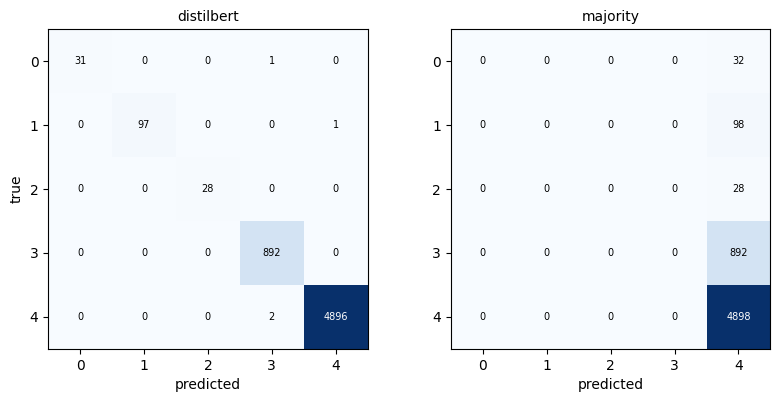

In [19]:
n = len(preds)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
axes = np.atleast_1d(axes)

for ax, (name, d) in zip(axes, preds.items()):
    cm = M.compute_metrics(d["true_id"], d["pred_id"])["confusion_matrix"]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(range(5))
    ax.set_yticklabels(range(5))
    ax.set_xlabel("predicted")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() * 0.6 else "black")

axes[0].set_ylabel("true")
plt.tight_layout()
plt.savefig("reports/figures/comparison_confusion_matrices.png", dpi=150)
plt.show()

## Step 5: ROC curves

Needs the probabilities, not the labels. 5 classes so it's one against the rest, averaged into one line per model.

Averaged across classes, not tweets, otherwise `sexual_violence` drowns everything out.

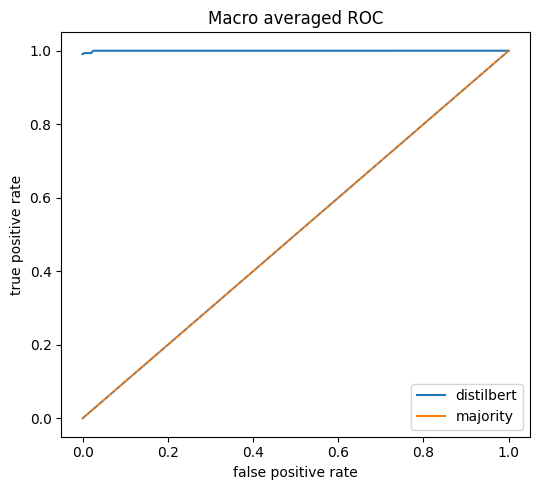

,model,auc_economic_violence,auc_emotional_violence,auc_harmful_traditional_practice,auc_physical_violence,auc_sexual_violence,macro_auc
0,distilbert,0.9993,1.0,1.0,1.0,1.0,0.9998
1,majority,0.5000,0.5,0.5,0.5,0.5,0.5000


In [20]:
grid = np.linspace(0, 1, 200)

def macro_roc(y, P):
    tprs = []
    for i in range(len(M.LABEL_ORDER)):
        fpr, tpr, _ = roc_curve((y == i).astype(int), P[:, i])
        tprs.append(np.interp(grid, fpr, tpr))
    return np.mean(tprs, axis=0)

auc_rows = []
plt.figure(figsize=(5.5, 5))

for name, d in preds.items():
    y = d["true_id"].values
    P = d[PROB_COLS].values
    plt.plot(grid, macro_roc(y, P), label=name)

    row = {"model": name}
    for i, label in enumerate(M.LABEL_ORDER):
        row[f"auc_{label}"] = roc_auc_score((y == i).astype(int), P[:, i])
    row["macro_auc"] = np.mean([row[f"auc_{l}"] for l in M.LABEL_ORDER])
    auc_rows.append(row)

plt.plot([0, 1], [0, 1], "--", color="grey", linewidth=1)
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Macro averaged ROC")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_roc.png", dpi=150)
plt.show()

auc = pd.DataFrame(auc_rows).sort_values("macro_auc", ascending=False).reset_index(drop=True)
auc.round(4)

## Step 6: Stress tests

I dropped the earlier idea of filtering out tweets that contain a keyword. Almost every tweet contains one, so the subset came out as a handful of tweets and told us nothing.

Instead each model runs the tests from `src/robustness.py` on its own and saves the result. This reads those files. Blank cells mean that model hasn't run them yet.

- **masked**: the strongest words per class replaced
- **random masked**: the same number of random words replaced, as the control
- **shuffled**: word order destroyed

In [ ]:
import json as _json

VARIANTS = ["masked", "random_masked", "shuffled"]

stress = []
for name, d in preds.items():
    row = {"model": name, "normal": M.compute_metrics(d["true_id"], d["pred_id"])["macro_f1"]}
    for v in VARIANTS:
        f = Path(f"reports/results/{name}_{v}_test.json")
        row[v] = _json.load(open(f))["macro_f1"] if f.exists() else None
    stress.append(row)

stress = pd.DataFrame(stress)
stress.round(4)

In [ ]:
plot_me = stress.dropna(subset=VARIANTS, how="all")
cols = ["normal"] + VARIANTS
x = np.arange(len(plot_me))
width = 0.8 / len(cols)

plt.figure(figsize=(7, 4))
for k, col in enumerate(cols):
    plt.bar(x + (k - len(cols) / 2) * width, plot_me[col].fillna(0), width, label=col.replace("_", " "))

plt.xticks(x, plot_me["model"], rotation=20, ha="right")
plt.ylabel("macro F1")
plt.title("What survives the stress tests")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/comparison_stress_tests.png", dpi=150)
plt.show()

## Step 7: What's being missed

The tweets each model gets wrong, for the error analysis.

In [25]:
text = pd.read_csv("data/processed/train_cleaned.csv")
lookup = text.set_index("Tweet_ID")["tweet_clean"]

for name, d in preds.items():
    wrong = d[d["true_id"] != d["pred_id"]]
    print(f"\n=== {name}: {len(wrong)} wrong out of {len(d)} ===")
    for _, r in wrong.head(3).iterrows():
        print(f"  {M.LABEL_ORDER[r['true_id']]} -> said {M.LABEL_ORDER[r['pred_id']]}")
        print(f"  {lookup[r['Tweet_ID']][:200]}")


=== distilbert: 0 wrong out of 2241 ===

=== majority: 177 wrong out of 2241 ===
  true physical_violence -> said sexual_violence
  when the cops show up, very few battered wives say, "my husband, right here, beats me "
  true physical_violence -> said sexual_violence
  hi kyle you are my favourite on you have it all , looks , fab husband , girls it beats me why you can't all get along ????you all have so much !!! but you have the most deffo in dreary england you bri
  true physical_violence -> said sexual_violence
  dear thelma: my husband cheats on me and beats me


In [26]:
table.to_csv("reports/results/model_comparison_all.csv", index=False)
auc.to_csv("reports/results/roc_auc_all.csv", index=False)
stress.to_csv("reports/results/stress_test_comparison.csv", index=False)
print("saved 3 tables and 3 figures")

saved 3 tables and 3 figures
